In [21]:
!pip3 install scikit-learn

In [22]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from IPython import display

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 14})
np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from hebb_net import HebbNet
from decoder_nets import LinearDecoder, NonlinearDecoder
from image_datasets import train_val_split, preprocess_nonlinear
from viz import draw_grid_image

In [ ]:
# Loading LFW dataset
lfw = fetch_lfw_people(min_faces_per_person=50, color=False)
images_raw = lfw.images
labels = lfw.target
target_names = lfw.target_names
n_classes = len(target_names)

print(f"Dataset has: {images_raw.shape[0]} images, and {n_classes} people")
print(f"IMGs Shape: {images_raw.shape[1:]}")
for i, name in enumerate(target_names):
    count = np.sum(labels == i)
    print(f"{count} images")

# Resize to 32x32
IMG_H, IMG_W, IMG_C = 32, 32, 1
images_resized = tf.image.resize(images_raw[..., np.newaxis], (IMG_H, IMG_W)).numpy()

# Min-max
images_norm = images_resized.astype(np.float32) / 255.0

# Split into train/test
from sklearn.model_selection import train_test_split
x_train_np, x_test_np, y_train_np, y_test_np = train_test_split(
    images_norm, labels, test_size=0.2, random_state=42, stratify=labels
)

train_mean = np.mean(x_train_np, axis=(0, 1, 2), keepdims=True)
x_train_np = x_train_np - train_mean
x_test_np = x_test_np - train_mean

# Flatten for HebbNet
M = IMG_H * IMG_W * IMG_C
x_train_flat = x_train_np.reshape(len(x_train_np), M)
x_test_flat = x_test_np.reshape(len(x_test_np), M)


x_train = tf.constant(x_train_flat, dtype=tf.float32)
y_train = tf.constant(y_train_np, dtype=tf.int32)
x_test = tf.constant(x_test_flat, dtype=tf.float32)
y_test = tf.constant(y_test_np, dtype=tf.int32)


x_train, y_train, x_val, y_val = train_val_split(x_train, y_train, prop_val=0.15)

print(f"\nShapes:")
print(f"  Train: {x_train.shape}, labels: {y_train.shape}")
print(f"  Val:   {x_val.shape}, labels: {y_val.shape}")
print(f"  Test:  {x_test.shape}, labels: {y_test.shape}")
print(f"  Features / image: {M}")

Dataset has: 1560 images, and 12 people
IMGs Shape: (62, 47)
77 images
236 images
121 images
530 images
109 images
71 images
52 images
55 images
53 images
60 images
52 images
144 images

Shapes:
  Train: (1061, 1024), labels: (1061,)
  Val:   (187, 1024), labels: (187,)
  Test:  (312, 1024), labels: (312,)
  Features / image: 1024


In [ ]:
NUM_NEURONS = 100
K = 3
INHIB = -0.4
EPOCHS = 300
LR = 0.5
SAVE_PATH = 'weights/lfw_wts.npy'
``
hebb_face = HebbNet(M, NUM_NEURONS, k=K, inhib_value=INHIB,
                    load_wts=False, saved_wts_path=SAVE_PATH)

hebb_face.fit(x_train, epochs=EPOCHS, mini_batch_sz=64, lr=LR,
              plot_wts_live=True, fig_sz=(10, 10), n_wts_plotted=(10, 10),
              print_every=5, save_wts=True, ds_feat_shape=(IMG_H, IMG_W, IMG_C))

SyntaxError: invalid syntax (3973850021.py, line 7)

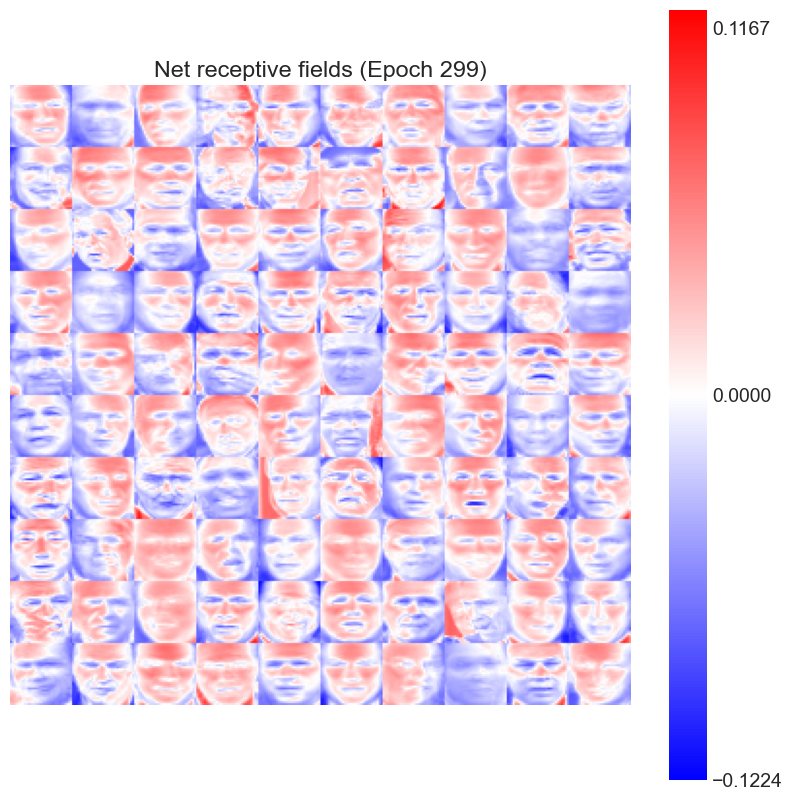

Epoch 300/300
Saving weights...Done!


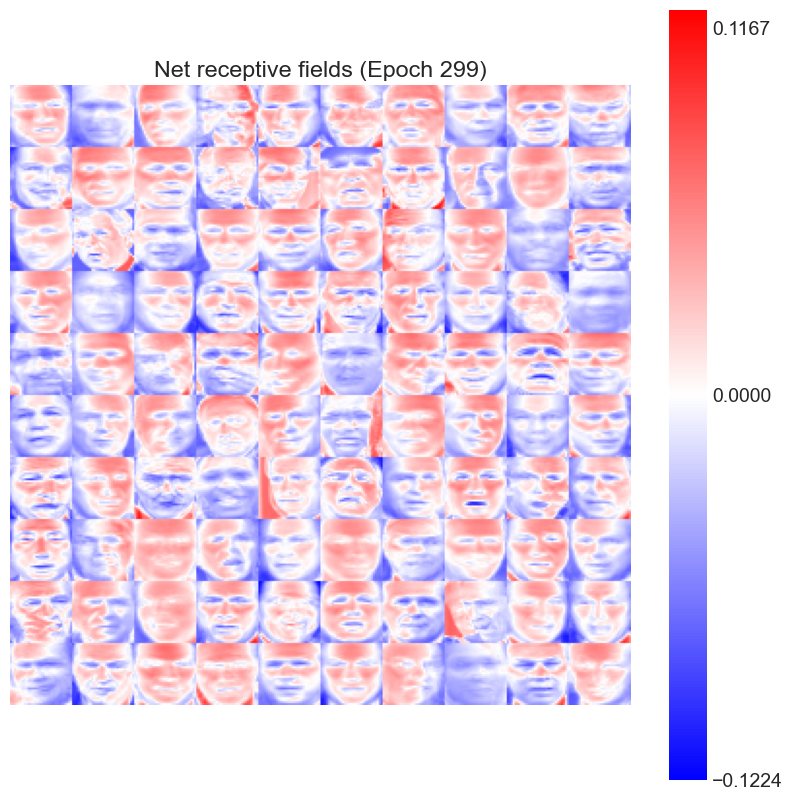

In [ ]:


hebb_face = HebbNet(M, NUM_NEURONS, k=K, inhib_value=INHIB,
                    load_wts=False, saved_wts_path=SAVE_PATH)

hebb_face.fit(x_train, epochs=EPOCHS, mini_batch_sz=64, lr=LR,
              plot_wts_live=True, fig_sz=(10, 10), n_wts_plotted=(10, 10),
              print_every=5, save_wts=True, ds_feat_shape=(IMG_H, IMG_W, IMG_C))

Loaded stored wts.


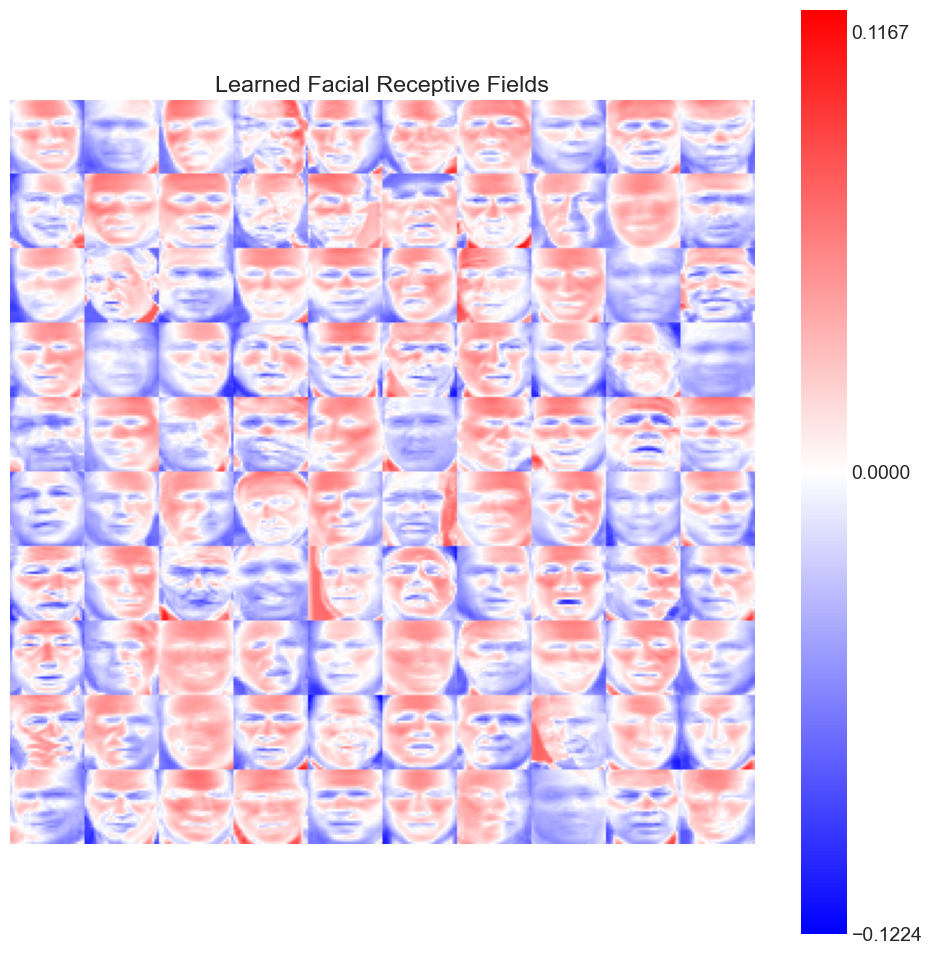

In [ ]:
hebb_face = HebbNet(M, NUM_NEURONS, k=K, inhib_value=INHIB,
                    load_wts=True, saved_wts_path=SAVE_PATH)

plt.figure(figsize=(12, 12))
draw_grid_image(tf.transpose(hebb_face.get_wts()), 10, 10,
                title='Learned Facial Receptive Fields',
                sample_dims=(IMG_H, IMG_W, IMG_C))
plt.show()

Neuron assignments per person:
  Sharon: 7 neurons (7.0%)
  Powell: 0 neurons (0.0%)
  Rumsfeld: 1 neurons (1.0%)
  Bush: 0 neurons (0.0%)
  Schroeder: 3 neurons (3.0%)
  Chavez: 4 neurons (4.0%)
  Chirac: 11 neurons (11.0%)
  Chretien: 34 neurons (34.0%)
  Ashcroft: 0 neurons (0.0%)
  Koizumi: 1 neurons (1.0%)
  Williams: 33 neurons (33.0%)
  Blair: 6 neurons (6.0%)


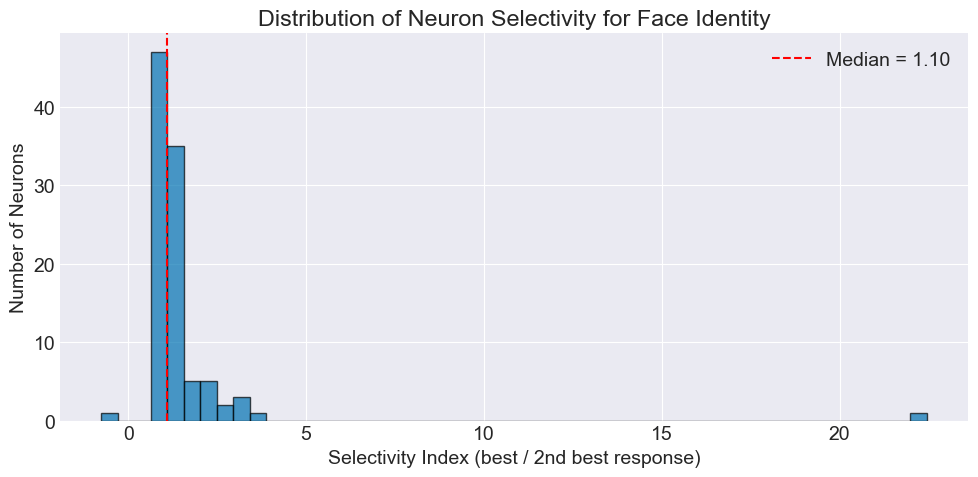

In [ ]:
# Compute net_in for all training + validation samples
all_x = tf.concat([x_train, x_val], axis=0)
all_y = tf.concat([y_train, y_val], axis=0).numpy()
net_in_all = hebb_face.net_in(all_x).numpy()

# Compute mean activation per person
mean_act_per_class = np.zeros((NUM_NEURONS, n_classes))
for c in range(n_classes):
    mask = all_y == c
    mean_act_per_class[:, c] = np.mean(net_in_all[mask], axis=0)

sorted_responses = np.sort(mean_act_per_class, axis=1)[:, ::-1]
selectivity = sorted_responses[:, 0] / (np.abs(sorted_responses[:, 1]) + 1e-10)

preferred_class = np.argmax(mean_act_per_class, axis=1)

print("Neuron assignments per person:")
for c in range(n_classes):
    count = np.sum(preferred_class == c)
    short_name = target_names[c].split()[-1]
    print(f"  {short_name}: {count} neurons ({count/NUM_NEURONS*100:.1f}%)")

# Histogram of selectivity
plt.figure(figsize=(10, 5))
plt.hist(selectivity, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Selectivity Index (best / 2nd best response)')
plt.ylabel('Number of Neurons')
plt.title('Distribution of Neuron Selectivity for Face Identity')
plt.axvline(np.median(selectivity), color='red', linestyle='--',
            label=f'Median = {np.median(selectivity):.2f}')
plt.legend()
plt.tight_layout()
plt.show()

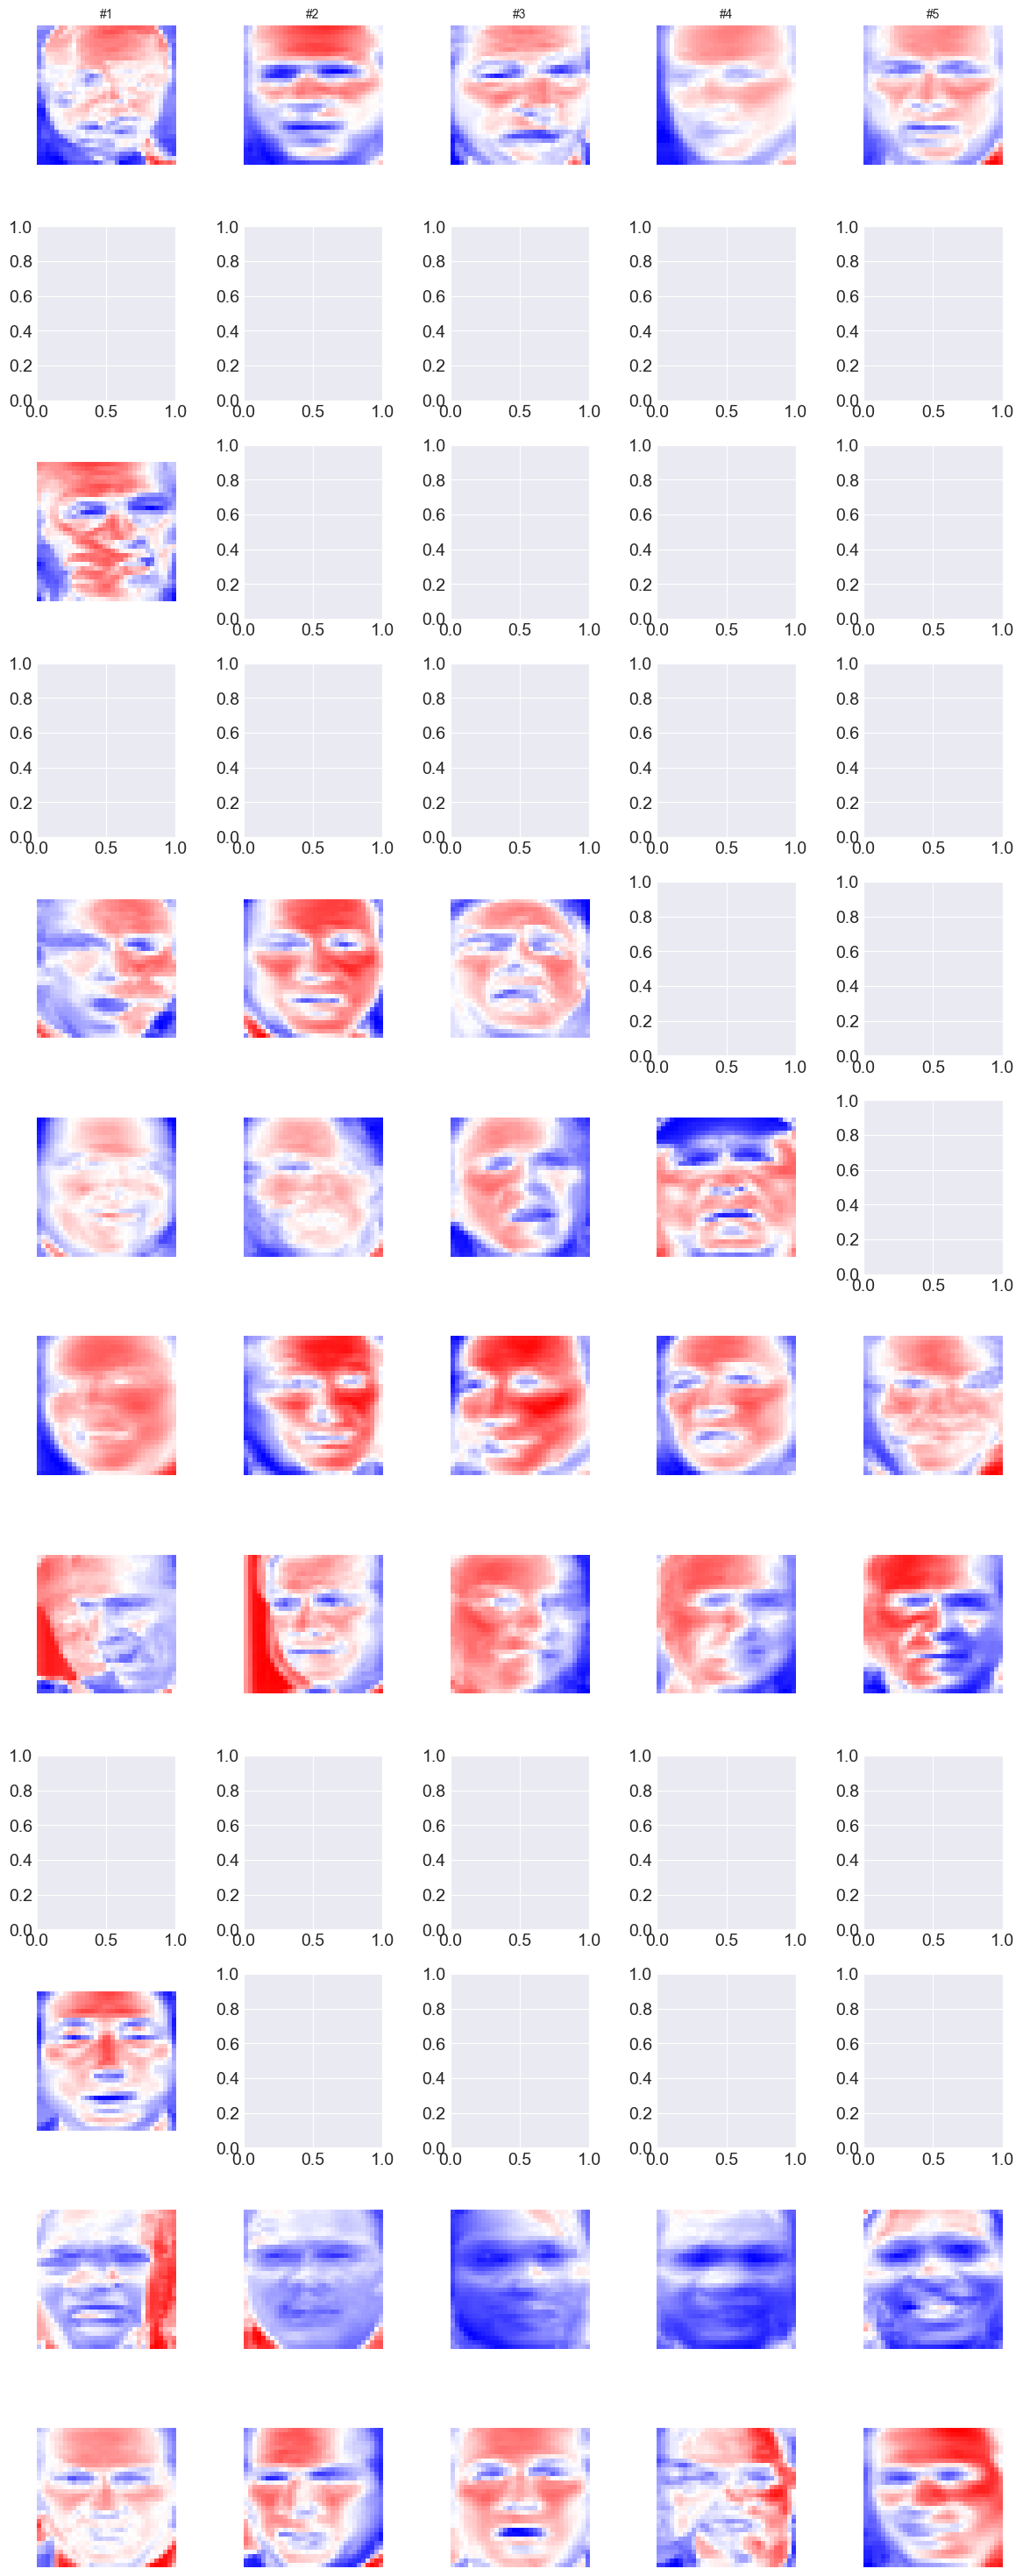

In [ ]:
# Top-5 most selective neurons for each person
wts = hebb_face.get_wts().numpy()

fig, axes = plt.subplots(n_classes, 5, figsize=(12, 2.5 * n_classes))
for c in range(n_classes):
    class_neurons = np.where(preferred_class == c)[0]
    class_selectivity = selectivity[class_neurons]
    top_idx = class_neurons[np.argsort(class_selectivity)[::-1][:5]]

    for j in range(min(5, len(top_idx))):
        neuron_idx = top_idx[j]
        ax = axes[c, j] if n_classes > 1 else axes[j]
        wt_img = wts[:, neuron_idx].reshape(IMG_H, IMG_W)
        vmax = np.max(np.abs(wt_img))
        ax.imshow(wt_img, cmap='bwr', vmin=-vmax, vmax=vmax)
        ax.axis('off')
        if j == 0:
            short_name = target_names[c].split()[-1]
            ax.set_ylabel(short_name, fontsize=10, rotation=0, labelpad=60)
        if c == 0:
            ax.set_title(f'#{j+1}', fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
hebb_train = hebb_face.net_in(x_train)
hebb_val = hebb_face.net_in(x_val)
hebb_test = hebb_face.net_in(x_test)

# Linear Decoder
tf.random.set_seed(0)
face_linear = LinearDecoder(input_feats_shape=(NUM_NEURONS,), C=n_classes)
face_linear.compile()

train_loss, val_loss, val_acc, epochs_run = face_linear.fit(
    hebb_train, y_train, x_val=hebb_val, y_val=y_val,
    batch_size=64, patience=7, lr_patience=4, lr_max_decays=4)

test_acc_lin, test_loss_lin = face_linear.evaluate(hebb_test, y_test)

---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 12]
---------------------------------------------------------------------------
Epoch 1/10000, Training loss 2.477, Val loss 2.471, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 2/10000, Training loss 2.459, Val loss 2.456, Val acc 0.3750. Epoch took: 0.1 secs
Epoch 3/10000, Training loss 2.448, Val loss 2.443, Val acc 0.3750. Epoch took: 0.1 secs
Epoch 4/10000, Training loss 2.429, Val loss 2.429, Val acc 0.3750. Epoch took: 0.1 secs
Epoch 5/10000, Training loss 2.415, Val loss 2.416, Val acc 0.3750. Epoch took: 0.1 secs
Epoch 6/10000, Training loss 2.401, Val loss 2.404, Val acc 0.3750. Epoch took: 0.1 secs
Epoch 7/10000, Training loss 2.382, Val loss 2.392, Val acc 0.3750. Epoch took: 0.1 secs
Epoch 8/10000, Training loss 2.379, Val loss 2.380, Val acc 0.3750. Epoch took: 0.1 secs
Epoch 9/10000, Training loss 2.365, Val loss 2.369, Val acc 0.3750. Epoch took: 0.1 secs

In [24]:
# Nonlinear Decoder
hebb_train_nl = preprocess_nonlinear(hebb_face.net_in(x_train))
hebb_val_nl = preprocess_nonlinear(hebb_face.net_in(x_val))
hebb_test_nl = preprocess_nonlinear(hebb_face.net_in(x_test))

tf.random.set_seed(0)
face_nonlinear = NonlinearDecoder((NUM_NEURONS,), n_classes, loss_exp=3.0)
face_nonlinear.output_layer.loss_exp = 3.0
face_nonlinear.compile(loss='lp')

train_loss_nl, val_loss_nl, val_acc_nl, epochs_nl = face_nonlinear.fit(
    hebb_train_nl, y_train, x_val=hebb_val_nl, y_val=y_val,
    batch_size=64, patience=9, lr_patience=5, lr_max_decays=4)

test_acc_nl, test_loss_nl = face_nonlinear.evaluate(hebb_test_nl, y_test)

---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 12]
---------------------------------------------------------------------------
Epoch 1/10000, Training loss 1.000, Val loss 1.000, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 2/10000, Training loss 1.000, Val loss 1.000, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 3/10000, Training loss 1.000, Val loss 1.000, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 4/10000, Training loss 1.000, Val loss 1.000, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 5/10000, Training loss 1.000, Val loss 1.000, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 6/10000, Training loss 0.999, Val loss 0.999, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 7/10000, Training loss 0.999, Val loss 0.999, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 8/10000, Training loss 0.999, Val loss 0.999, Val acc 0.3750. Epoch took: 0.2 secs
Epoch 9/10000, Training loss 0.999, Val loss 0.999, Val acc 0.3750. Epoch took: 0.1 secs